# Ocean colour Climatology and Bathymetry
## Core 3 CS- Saldanha Bay Coastal Region
This notebook forms a part of the SAMS Core 3 Capstone Group assignment.
The objective is to visualise and analyse climatological satellite-derived
chlorophyll concentrations together with bathymetric information for a
coastal region of interest.
**Region:** Saldanha Bay and adjacent West Coast of South Africa





In [7]:
# Import core scientific Python libraries
import xarray as xr               # For working with NetCDF data
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Plotting
import cartopy.crs as ccrs        # Map projections
import cartopy.feature as cfeature
import cmocean                    # Oceanographically appropriate colormaps
from scipy.ndimage import gaussian_filter

## Bathymetry (GMRT)

Bathymetry describes the depth and shape of the seafloor and provides
important physical context for interpreting chlorophyll distributions.
In this section, bathymetric data from the Global Multi-Resolution
Topography (GMRT) dataset are loaded, inspected, and visualised for the
Saldanha Bay region.

In [2]:

# Define data directory relative to repository
DATA_DIR = "Capstone_Assesment/"

# Define dataset paths
bathy_path = DATA_DIR + "GMRTv4_4_1_20260516topo.grd"
chl_path = DATA_DIR + "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc"

# Check if files exist 
import os

if not os.path.exists(bathy_path):
    raise FileNotFoundError(
        f"Bathymetry file not found at {bathy_path}. "
        "Place it inside the Capstone_Assesment folder."
    )

if not os.path.exists(chl_path):
    raise FileNotFoundError(
        f"Chlorophyll file not found at {chl_path}. "
        "Place it inside the Capstone_Assesment folder."
    )

In [3]:
# Load GMRT bathymetry data from a GMT grid (.grd) file.
# Although the file extension is .grd, it follows NetCDF conventions
# and can be read directly using xarray.

bathy = xr.open_dataset(bathy_path)

bathy


<xarray.Dataset> Size: 640MB
Dimensions:    (side: 2, xysize: 80046080)
Dimensions without coordinates: side, xysize
Data variables:
    x_range    (side) float64 16B ...
    y_range    (side) float64 16B ...
    z_range    (side) float64 16B ...
    spacing    (side) float64 16B ...
    dimension  (side) int32 8B ...
    z          (xysize) float64 640MB ...
Attributes:
    title:    GMRT Grid
    source:   \n\tProjection: Cylindrical Equidistant\n\tCreated with GMRT Ma...

### Bathymetry Dataset Description

The bathymetry data were obtained from the Global Multi-Resolution
Topography (GMRT) synthesis using the GMRT MapTool.

The dataset is provided as a GMT grid (`.grd`) file. Although this
differs from the standard `.nc` extension, the file follows NetCDF
conventions and is fully compatible with xarray.

The primary variable represents seafloor elevation, where negative
values indicate ocean depth.

In [4]:
# Identify the available data variables in the bathymetry dataset

list(bathy.data_vars)


['x_range', 'y_range', 'z_range', 'spacing', 'dimension', 'z']

In [5]:
# Extract grid dimensions (number of points in x and y)
nx, ny = bathy.dimension.values
nx, ny


(np.int32(10240), np.int32(7817))

In [6]:
# Reshape the bathymetry data into a 2D grid
z = bathy.z.values.reshape((ny, nx))

z.shape


(7817, 10240)

In [8]:
# --- Extract metadata ---
nx, ny = bathy.dimension.values
x_min, x_max = bathy.x_range.values
y_min, y_max = bathy.y_range.values

# --- Reshape ---
z = bathy.z.values.reshape(ny, nx).astype(np.float32)
z = np.flipud(z)

# --- Coordinates ---
lon = np.linspace(x_min, x_max, nx)
lat = np.linspace(y_min, y_max, ny)

# --- Region ---
lon_min, lon_max = 16.0, 18.5
lat_min, lat_max = -34.5, -31.5

lon_idx = np.where((lon >= lon_min) & (lon <= lon_max))[0]
lat_idx = np.where((lat >= lat_min) & (lat <= lat_max))[0]

lon_i0, lon_i1 = lon_idx[0], lon_idx[-1]
lat_i0, lat_i1 = lat_idx[0], lat_idx[-1]

In [9]:
# --- Crop ---
z_crop = z[lat_i0:lat_i1+1, lon_i0:lon_i1+1]

# Smooth ocean properly
z_smooth = gaussian_filter(z_crop, sigma=1)

# --- Meshgrid for contour plotting ---
lon_crop = np.linspace(lon_min, lon_max, z_crop.shape[1])
lat_crop = np.linspace(lat_min, lat_max, z_crop.shape[0])
LON, LAT = np.meshgrid(lon_crop, lat_crop)

# Colormap
cmap = cmocean.cm.deep_r

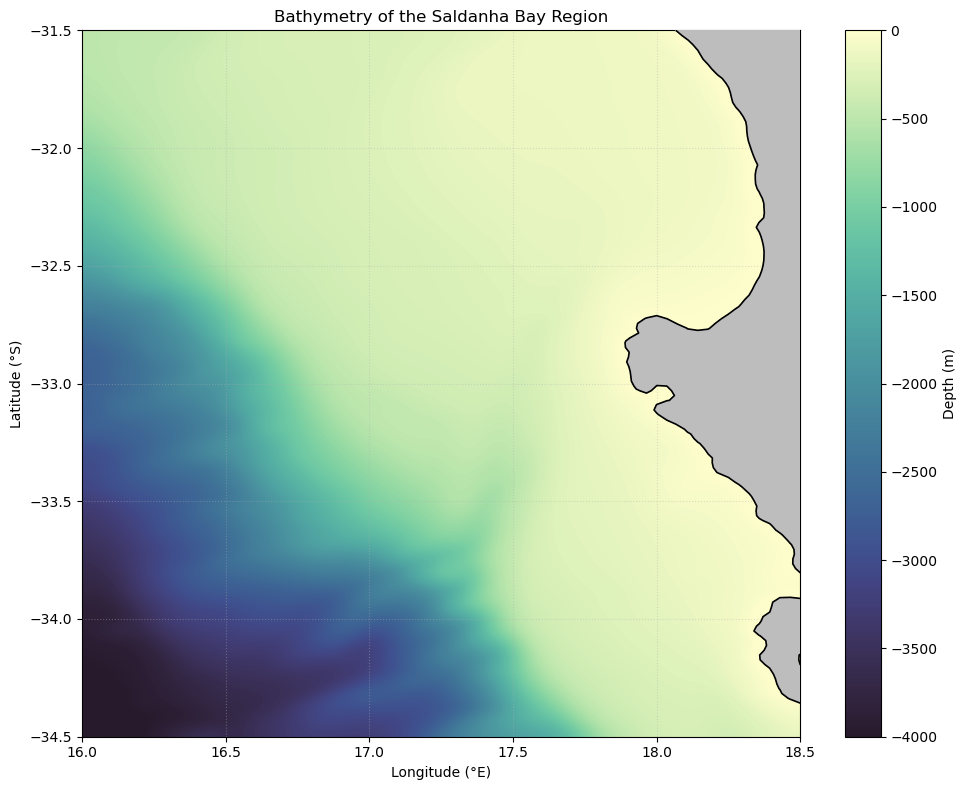

In [10]:
# --- Plot ---
plt.figure(figsize=(10, 8))

#1. Smooth ocean
im = plt.imshow(
    z_smooth,
    origin="lower",
    cmap=cmap,
    vmin=-4000,
    vmax=0,
    extent=[lon_min, lon_max, lat_min, lat_max],
    interpolation="bicubic",
    aspect="auto"
)

# 2. Overlay SMOOTH LAND (this is the key fix)
plt.contourf(
    LON,
    LAT,
    z_crop,
    levels=[0, z_crop.max()],
    colors=['#bdbdbd'],   # grey land
    zorder=3
)

# 3. Smooth coastline line
plt.contour(
    LON,
    LAT,
    z_crop,
    levels=[0],
    colors='black',
    linewidths=1.2,
    zorder=4
)

# --- Colorbar ---
plt.colorbar(im, label="Depth (m)")

# --- Labels ---
plt.title("Bathymetry of the Saldanha Bay Region")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°S)")
plt.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/bathymetry_saldanha.png", dpi=300)
plt.show()

# Map of the mean annual chlorophyll

In [11]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from matplotlib.colors import LogNorm

In [12]:
# FILE PATHS (WORKS FOR EVERYONE IN GROUP)

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Capstone_Assesment")

chl_path = os.path.join(DATA_DIR, "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Check file exists
if not os.path.exists(chl_path):
    raise FileNotFoundError(f"Chlorophyll file not found at: {chl_path}")

print("File found:", chl_path)

File found: C:\Users\Student\Documents\BIOL5012W 2026\Core 3\Core 3.3- Python\SAMOS2026-Core3CS-SALDANA-BAY\Capstone_Assesment\ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc


In [13]:
# LOAD CHLOROPHYLL DATA

ds = xr.open_dataset(chl_path)
chl = ds['chlor_a']

print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
  

In [14]:
# Check latitude order (important debug step)
print("Latitude range:", chl.lat.min().values, chl.lat.max().values)

Latitude range: -89.97916666666666 89.97916666666667


In [15]:
# SUBSET REGION: SALDANHA BAY

# Correct slicing 
subset = chl.sel(
    lon=slice(16.0, 18.5),
    lat=slice(-31.5, -34.5)   
)

print(subset)

<xarray.DataArray 'chlor_a' (time: 12, lat: 72, lon: 60)> Size: 207kB
[51840 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 576B -31.52 -31.56 -31.6 ... -34.4 -34.44 -34.48
  * lon      (lon) float64 480B 16.02 16.06 16.1 16.15 ... 18.4 18.44 18.48
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


In [16]:
# Remove invalid values (required for LogNorm)
subset = subset.where(subset > 0)

# Compute annual mean 
chl_mean = subset.mean(dim='time')

#  Debug check 
print("Min:", float(chl_mean.min()))
print("Max:", float(chl_mean.max()))

Min: 0.2947520911693573
Max: 9.130475044250488


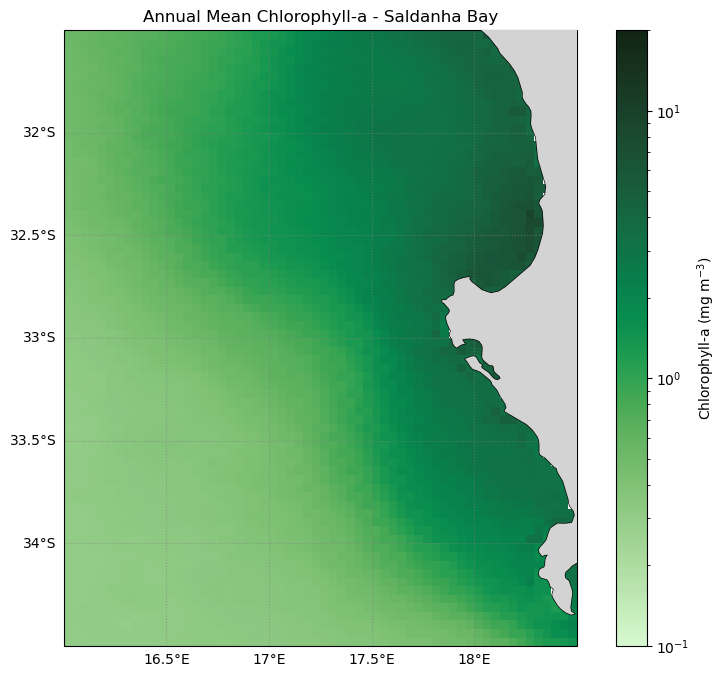

In [17]:
# CLEAN ANNUAL MEAN CHLOROPHYLL MAP

import cartopy.feature as cfeature

plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

chl_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.algae,
    norm=LogNorm(vmin=0.1, vmax=20),
    cbar_kwargs={'label': 'Chlorophyll-a (mg m$^{-3}$)'}
)


# Add gridlines with latitude/longitude labels
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.8,
    linestyle=':',
    color='gray',
    alpha=0.6
)

# Show labels only on left and bottom (clean look)
gl.top_labels = False
gl.right_labels = False

# Optional: improve label font size
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Clean coastline
ax.coastlines(resolution='10m', linewidth=1)

# Mask land 
ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=3)

# Title
ax.set_title("Annual Mean Chlorophyll-a - Saldanha Bay")

# Ensure figures folder exists (prevents save errors)
import os
os.makedirs("figures", exist_ok=True)

# Save
plt.savefig("figures/chl_annual_mean.png", dpi=300, bbox_inches="tight")

plt.show()

# A faceted figure, showing 12 maps, one for each month showing spatial distribution of chlorophyll-a concentration across the study region



In [1]:
# 1. Open the dataset
import xarray as xr
ds = xr.open_dataset("Capstone_Assesment/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

In [2]:
#Extracts the chlorophyll variable from the dataset
chl = ds['chlor_a']   


In [3]:
#check coordinates range
print(ds['lat'].values.min(), ds['lat'].values.max())
print(ds['lon'].values.min(), ds['lon'].values.max())

-89.97916666666666 89.97916666666667
-179.97916666666666 179.97916666666663


In [4]:
#Subset the chlorophyll dataset to the study area Saldanha Bay to reduce 
#the dataset to the spatial extent 16°E–18.5°E, 31.5°S–34.5°S

subset = chl.sel(lon=slice(16.0, 18.5), lat=slice(-31.5, -34.5))


In [5]:
print(subset)


<xarray.DataArray 'chlor_a' (time: 12, lat: 72, lon: 60)> Size: 207kB
[51840 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 576B -31.52 -31.56 -31.6 ... -34.4 -34.44 -34.48
  * lon      (lon) float64 480B 16.02 16.06 16.1 16.15 ... 18.4 18.44 18.48
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


In [6]:
print(subset.shape)
print(float(subset.min()), float(subset.max()))

(12, 72, 60)
0.1831902116537094 20.567155838012695


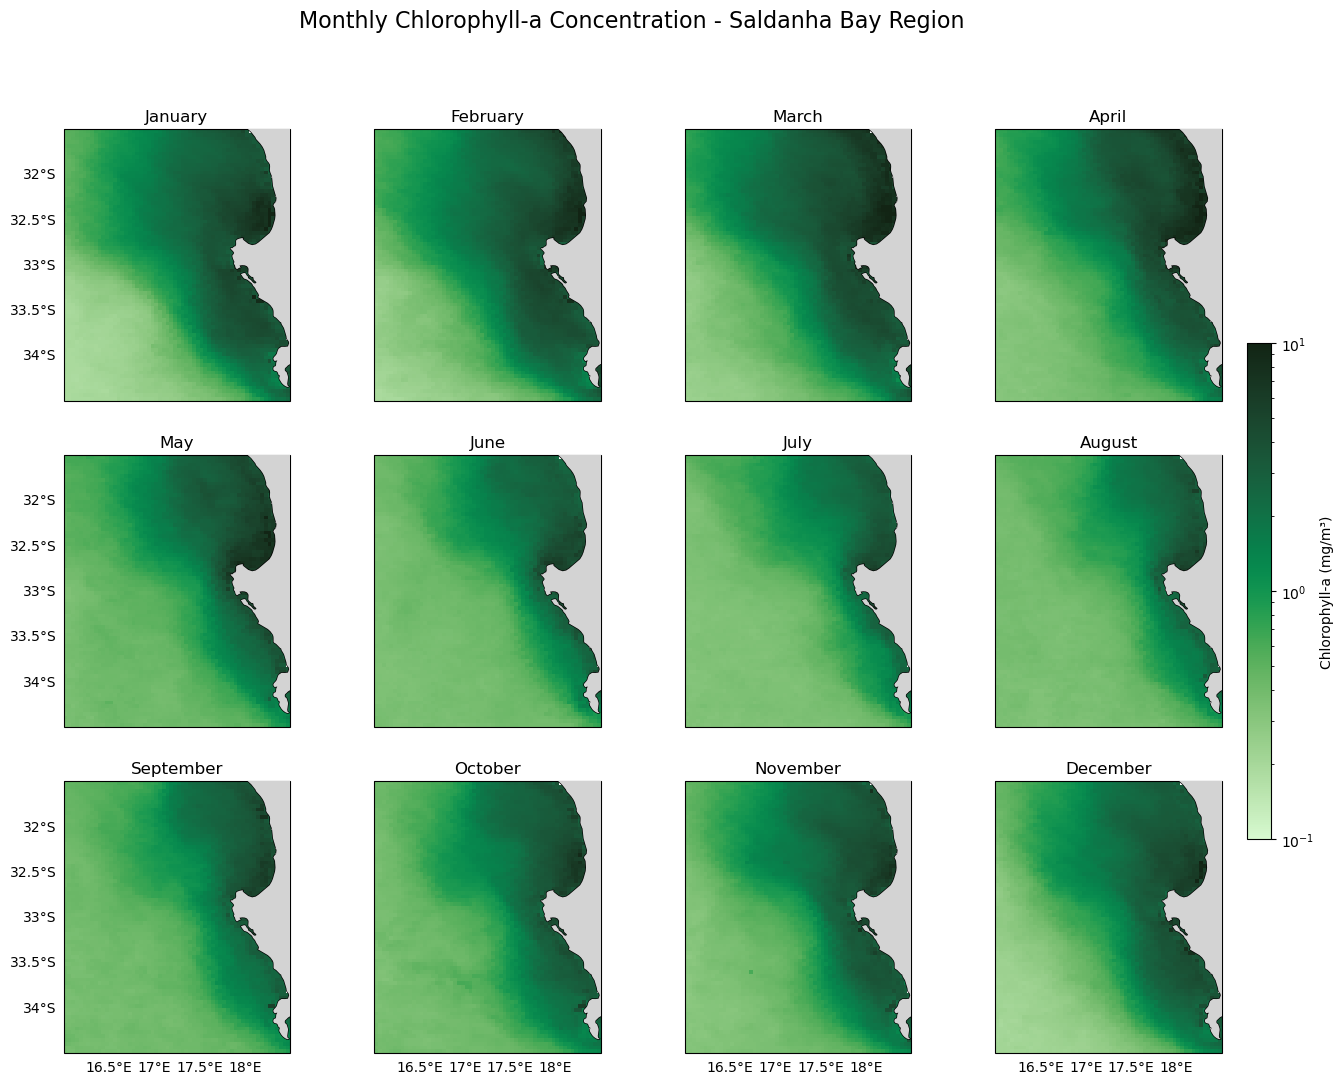

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import pandas as pd
import cmocean 
# Open dataset ESACCI-OC-MAPPED-CIMATOLOGY.nc
ds = xr.open_dataset("Capstone_Assesment/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Faceted plot
fig, axes = plt.subplots(
    nrows=3, ncols=4, figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

im = None

for i, ax in enumerate(axes):
    da = subset.isel(time=i)
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.algae,
        norm=LogNorm(vmin=0.1, vmax=10),
        add_colorbar=False   
    )
     # Add land and coastline
    ax.add_feature(
        cfeature.LAND.with_scale("10m"), 
        facecolor="lightgrey", zorder=3
    )
    ax.coastlines(resolution="10m", color="black", linewidth=1)

    # Labels only on outer edges
    gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 4 == 0)      # left column only
    gl.bottom_labels = (i >= 8)        # bottom row only

    # Month title
    date = pd.to_datetime(da['time'].values)
    ax.set_title(date.strftime("%B"))

# Shared vertical colorbar on the right side
plt.suptitle("Monthly Chlorophyll-a Concentration - Saldanha Bay Region", fontsize=16)
plt.subplots_adjust(right=0.9) 
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Chlorophyll-a (mg/m³)")
plt.savefig("figures/chl_monthly.png", dpi=300, bbox_inches="tight")
plt.show()


# A timeseries plot showing two lines: the mean seasonal cycle of the whole region compared with the time series from a single grid point of high chlorophyll


In [15]:
regional_mean = subset.mean(dim=['lat','lon'])

In [16]:
point_ts = subset.sel(lon=17.0, lat=-33.0, method='nearest')


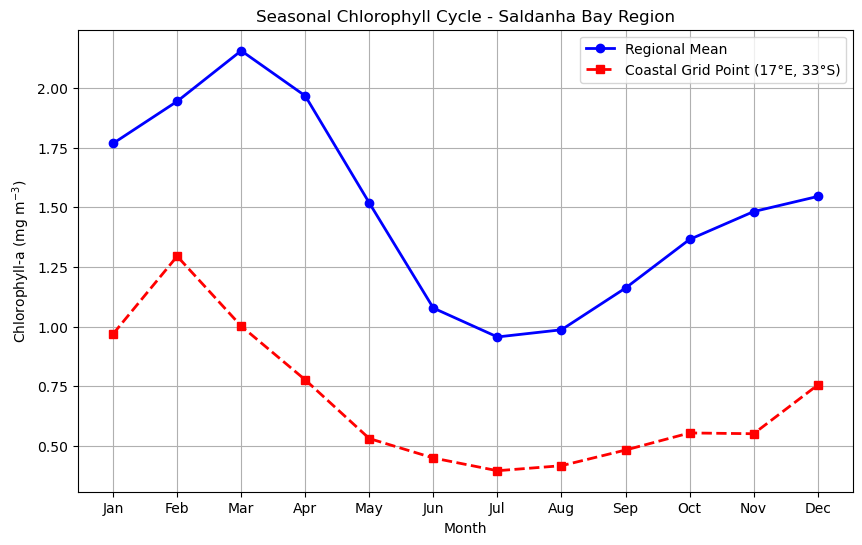

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Month index
months = np.arange(12)

plt.figure(figsize=(10,6))

# Regional mean
plt.plot(months, regional_mean,
         label="Regional Mean",
         linewidth=2,
         marker='o',
         color='blue')
# Coastal point
plt.plot(months, point_ts,
         label="Coastal Grid Point (17°E, 33°S)",
         linewidth=2,
         linestyle='--',
         marker='s',
         color='red')

# Labels
plt.title("Seasonal Chlorophyll Cycle - Saldanha Bay Region")
plt.xlabel("Month")
plt.ylabel("Chlorophyll-a (mg m$^{-3}$)")

# Month labels
plt.xticks(
    months,
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.legend()
plt.grid(True)

# Save figure
plt.savefig("figures/chl_timeseries.png", dpi=300, bbox_inches="tight")

plt.show()